# Домашнє завдання: Візуалізація даних з Pandas

## Опис завдання
У цьому домашньому завданні ви працюватимете з датасетом про оренду велосипедів `yulu_rental.csv`. Датасет містить інформацію про кількість орендованих велосипедів залежно від погодних умов, сезону та інших факторів.
Набір даних взяти з Kaggle. Посилання на оригінальний [опис](https://www.kaggle.com/datasets/ranitsarkar01/yulu-bike-sharing-data?select=yulu_bike_sharing_dataset.csv).

**Опис колонок:**
- `datetime` - дата та час
- `season` - квартал (1-Q1, 2-Q2, 3-Q3, 4-Q4)
- `holiday` - чи є день святковим (0=ні, 1=так)
- `workingday` - чи є день робочим (0=ні, 1=так)
- `weather` - погодні умови (1=ясно, 2=туман, 3=легкий дощ, 4=сильний дощ)
- `temp` - температура в градусах Цельсія
- `atemp` - відчувається як температура
- `humidity` - вологість (%)
- `windspeed` - швидкість вітру
- `casual` - кількість випадкових користувачів
- `registered` - кількість зареєстрованих користувачів
- `count` - загальна кількість орендованих велосипедів



---
🌱 Коментар щодо сезонності

Колонка season у датасеті представляє саме квартали року, а не метеорологічні сезони. Тому всі аналізи сезонності ви можете будувати на основі кварталів.

Водночас дані були зібрані в Індії, де поділ на сезони інший, ніж у Європі чи США. Якщо ви хочете дослідити сезонність відповідно до індійської системи сезонів, можна створити окрему колонку.


Справжні сезони в Індії:

| Сезон        | Місяці                     |
| ------------ | -------------------------- |
| Winter       | December–February (12,1,2) |
| Summer       | March–May (3,4,5)          |
| Monsoon      | June–September (6,7,8,9)   |
| Post-monsoon | October–November (10,11)   |


Тоді потрібно зробити нову колонку weather_season_india, мапнувши місяці так:

12, 1, 2 → 1 (Winter)

3, 4, 5 → 2 (Summer)

6–9 → 3 (Monsoon)

10–11 → 4 (Post-Monsoon)

## Підготовка даних


In [46]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [47]:
import pandas as pd
import matplotlib.pyplot as plt

# Завантаження даних
df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/data/yulu_rental.csv')

In [48]:
df.head()

,datetime,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count
0,2011-01-01 00:00:00,1,0,0,1,9.84,14.395,81,0.0,3,13,16
1,2011-01-01 01:00:00,1,0,0,1,9.02,13.635,80,0.0,8,32,40
2,2011-01-01 02:00:00,1,0,0,1,9.02,13.635,80,0.0,5,27,32
3,2011-01-01 03:00:00,1,0,0,1,9.84,14.395,75,0.0,3,10,13
4,2011-01-01 04:00:00,1,0,0,1,9.84,14.395,75,0.0,0,1,1


In [49]:
# Перетворення datetime у правильний формат
df['datetime'] = pd.to_datetime(df['datetime'])
df.set_index('datetime', inplace=True)

# Додамо додаткові колонки для аналізу
df['date'] = df.index.date
df['day'] = df.index.day
df['week'] = df.index.isocalendar().week
df['weekday_num'] = df.index.weekday
df['weekday'] = df.index.day_name()
df['year'] = df.index.year
df['month'] = df.index.month
df['hour'] = df.index.hour

## Завдання 0: Перегляд даних
**Завдання:**
Перегляньте дані, їх розмір, та напишіть висновок:
- скільки даних в наборі
- який рівень деталізації мають ці дані, тобто за який період міститься дані в одному рядку даних ?

In [50]:
df

,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count,date,day,week,weekday_num,weekday,year,month,hour
datetime,,,,,,,,,,,,,,,,,,,
2011-01-01 00:00:00,1,0,0,1,9.84,14.395,81,0.0000,3,13,16,2011-01-01,1,52,5,Saturday,2011,1,0
2011-01-01 01:00:00,1,0,0,1,9.02,13.635,80,0.0000,8,32,40,2011-01-01,1,52,5,Saturday,2011,1,1
2011-01-01 02:00:00,1,0,0,1,9.02,13.635,80,0.0000,5,27,32,2011-01-01,1,52,5,Saturday,2011,1,2
2011-01-01 03:00:00,1,0,0,1,9.84,14.395,75,0.0000,3,10,13,2011-01-01,1,52,5,Saturday,2011,1,3
2011-01-01 04:00:00,1,0,0,1,9.84,14.395,75,0.0000,0,1,1,2011-01-01,1,52,5,Saturday,2011,1,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2012-12-19 19:00:00,4,0,1,1,15.58,19.695,50,26.0027,7,329,336,2012-12-19,19,51,2,Wednesday,2012,12,19
2012-12-19 20:00:00,4,0,1,1,14.76,17.425,57,15.0013,10,231,241,2012-12-19,19,51,2,Wednesday,2012,12,20
2012-12-19 21:00:00,4,0,1,1,13.94,15.910,61,15.0013,4,164,168,2012-12-19,19,51,2,Wednesday,2012,12,21


У датафреймі знаходиться набір даних за період з 01.01.2011р. по 19.12.2012 р., складається з 10 886 рядочків.
У кожному рядочку деталізується інформація за 1 годину певної дати.

## Завдання 1: Базовий лінійний графік

**Завдання:**
1. Згрупуйте дані про кількість орендованих велосипедів (`count`) поденно.
2. Побудуйте з методом `DataFrame.plot()` лінійний графік поденної кількості орендованих велосипедів (`count`) за весь період в даних.
3. Налаштуйте розмір графіка (12x6), додайте заголовок "Динаміка оренди велосипедів" та сітку.
4. Дайте відповіді на питання по цьому графіку. Якщо треба - проведіть додаткові програмні операції для відповідей.

**Питання для інтерпретації:**
1. Як гадаєте, чому графік має "заломи", чим це спричинено і як ви б могли прибрати заломи?
2. Які загальні тенденції ви бачите на графіку?
3. Чи помітні якісь сезонні коливання?
4. Чи є періоди з аномально високими або низькими значеннями і чому на ваш погляд можуть бути ці аномалії?


In [51]:
# Щоденна оренда велосипедів:

day_count = df['count'].resample('D').sum()

In [52]:
day_count.head()

,count
datetime,
2011-01-01,985
2011-01-02,801
2011-01-03,1349
2011-01-04,1562
2011-01-05,1600


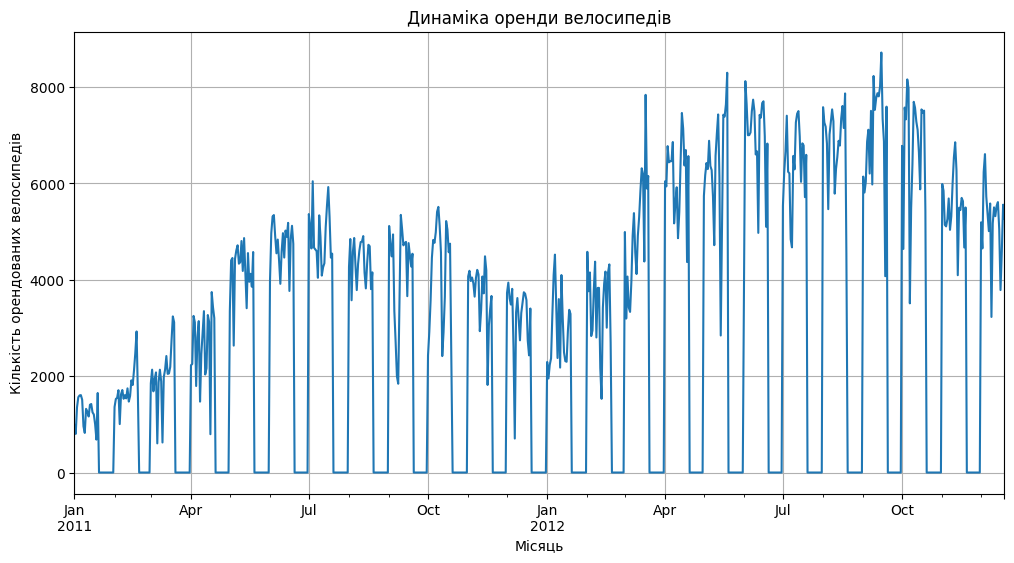

In [53]:
day_count.plot(                                  # Графік щоденної оренди велосипедів
    kind='line',
    figsize=(12, 6),
    title='Динаміка оренди велосипедів',
    xlabel='Місяць',
    ylabel='Кількість орендованих велосипедів',
    grid=True
);

Питання для інтерпретації:

1. Як гадаєте, чому графік має "заломи", чим це спричинено і як ви б могли прибрати заломи?

Заломи графіку пов'язані із тим, що деякі дні сервіс міг не працювати (якісь святкові неробочі дні, або вихідні сервісу), також могла впливати погода (в холодні, дощові дні велосипеди могли не орендуватись зовсім). Тому в ці дні оренда=0, і графік має заломи.

2. Які загальні тенденції ви бачите на графіку?

Загалом спостерігається зростаюча динаміка за весь період наявних даних.

3. Чи помітні якісь сезонні коливання?

На графіку помітна сезонність. Попит зростає в квітня по жовтень, а в осінні та зимові місяці попит падає. Піки припадають на теплі літні місяці.

4. Чи є періоди з аномально високими або низькими значеннями і чому на ваш погляд можуть бути ці аномалії?

Регулярні провали до 0 спостерігаються протягом всього року. Найімовірніше це пов'язано із днями, коли прокат повністю зачинений, або із експтремальними погодними умовами.

Прибрати заломи у графіку можна загрегувавши дані помісячно.
За таким графіком дуже добре видно позитивну динаміку за весь період спостережень. Також дуже добре видно сезонність цього бізнесу.

In [54]:
# Щомісячна оренда велосипедів:

month_count = df['count'].resample('ME').sum()

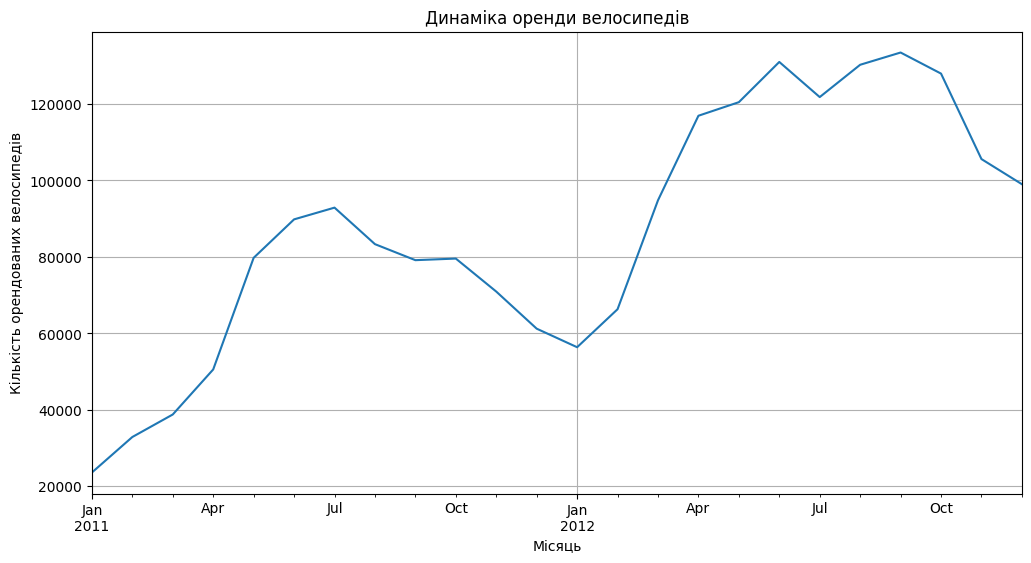

In [55]:
month_count.plot(                                  # Графік щомісячної оренди велосипедів
    kind='line',
    figsize=(12, 6),
    title='Динаміка оренди велосипедів',
    xlabel='Місяць',
    ylabel='Кількість орендованих велосипедів',
    grid=True
);


## Завдання 2: Аналіз сезонності (Bar Plot)

**Завдання:**
Побудуйте вертикальну стовпчасту діаграму середньої кількості орендованих велосипедів за сезонами(кварталами). Додайте підписи осей і заголовок.

Просунуте доповнення:
1. Позначте квартали не числом, а назвою на візуалізації.
2. Додайте підписи над стовпцями зі значеннями в кожному стовпці.

Дайте відповіді на питання нижче.

**Питання для інтерпретації:**
1. В який квартал найбільша середня кількість оренди велосипедів?
2. Як ви можете пояснити таку сезонну закономірність?
3. У скільки разів відрізняється оренда між найпопулярнішим та найменш популярним кварталми?

In [56]:
# Середня кількість орендованих велосипедів за кварталами:

quart_mean = df['count'].resample('QE').mean()

In [57]:
quart_mean

,count
datetime,
2011-03-31,71.905518
2011-06-30,160.940746
2011-09-30,186.994872
2011-12-31,154.787125
2012-03-31,159.476889
2012-06-30,269.601757
2012-09-30,281.735380
2012-12-31,243.189466


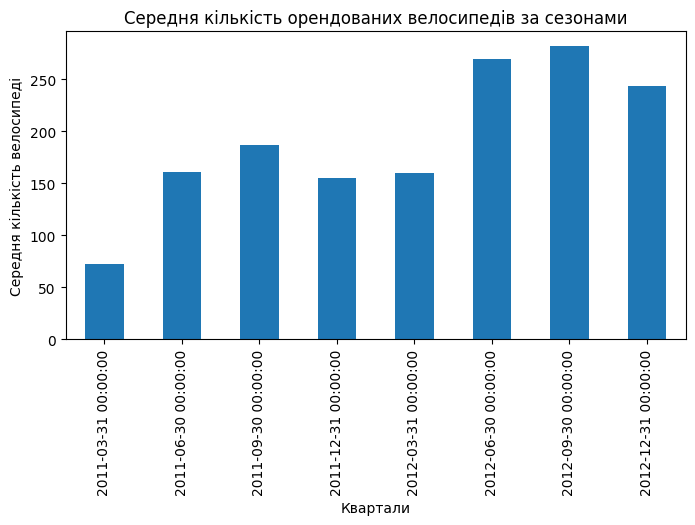

In [58]:
quart_mean.plot.bar(
    figsize=(8,4),
    title='Середня кількість орендованих велосипедів за сезонами',
    ylabel='Середня кількість велосипеді',
    xlabel='Квартали'
);

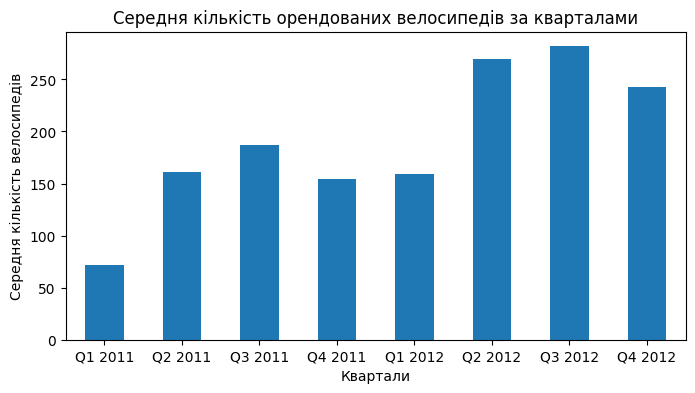

In [59]:
                     # Перезаписуємо індекс власними назвами
quart_mean.index = ['Q1 2011', 'Q2 2011', 'Q3 2011', 'Q4 2011',
                    'Q1 2012', 'Q2 2012', 'Q3 2012', 'Q4 2012']

quart_mean.plot.bar(
    figsize=(8, 4),
    title='Середня кількість орендованих велосипедів за кварталами',
    ylabel='Середня кількість велосипедів',
    xlabel='Квартали',
    rot=0
);

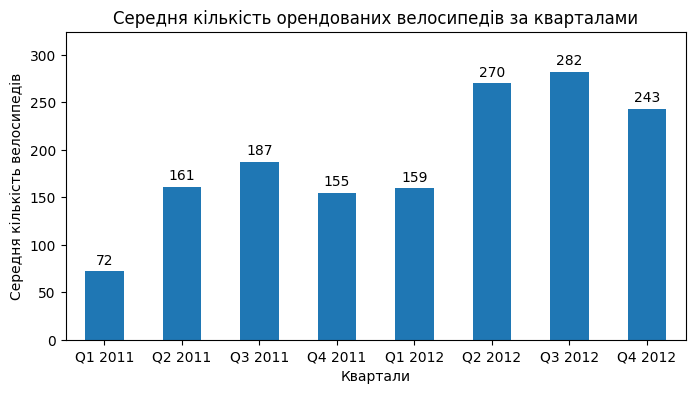

In [60]:
                     # Перезаписуємо індекс власними назвами
quart_mean.index = ['Q1 2011', 'Q2 2011', 'Q3 2011', 'Q4 2011',
                    'Q1 2012', 'Q2 2012', 'Q3 2012', 'Q4 2012']

# Присвоюємо результат змінній ax
ax = quart_mean.plot.bar(
    figsize=(8, 4),
    title='Середня кількість орендованих велосипедів за кварталами',
    ylabel='Середня кількість велосипедів',
    xlabel='Квартали',
    rot=0,
    ylim=(0, quart_mean.max() * 1.15)      # піднімаємо верхню межу, щоб числа вмістилися
)

# Додаємо значення над стовпчиками (потрібно використати метод bar_label)
ax.bar_label(ax.containers[0], fmt='%.0f', padding=3);

Питання для інтерпретації:

1. В який квартал найбільша середня кількість оренди велосипедів?

Найбільша середня кількість оренди велосипедів спостерігається у третьому кварталі кожного року (період з 1 липня по 30 вересня).

2. Як ви можете пояснити таку сезонну закономірність?

У цей період найбільш сприятливі погодні умови для користування велосипедами.

3. У скільки разів відрізняється оренда між найпопулярнішим та найменш популярним кварталами?

майже в 4 рази (282/72 = 3,92).

## Завдання 3: Динаміка за місяцями (Line Plot)

**Завдання:**
Створіть лінійний графік середньої кількості оренд велосипедів на годину по місяцях (тобто групування в рамках місяця і беремо середню кількість оренд у цей місяць з кількох років). Використайте маркери-кружечки для точок, додайте сітку та пофарбуйте лінію у червоний колір.

Просунуте доповнення:
- додайте аби по осі ОХ поділки були чітко на кожен окремий місяць по одній. Тобто сумарно 12 поділок.

Дайте відповіді на питання нижче.

**Питання для інтерпретації:**
1. В які місяці спостерігається пік та спад оренди?
2. Чи збігається ця закономірність з результатами з попереднього завдання?
3. Як може вплинути клімат на оренду велосипедів протягом року?


In [61]:
# Групуємо дані за місяцями (1-12) та рахуємо середнє:

monthly_avg = df['count'].groupby(df.index.month).mean()

In [62]:
monthly_avg

,count
datetime,
1,90.366516
2,110.003330
3,148.169811
4,184.160616
5,219.459430
6,242.031798
7,235.325658
8,234.118421
9,233.805281


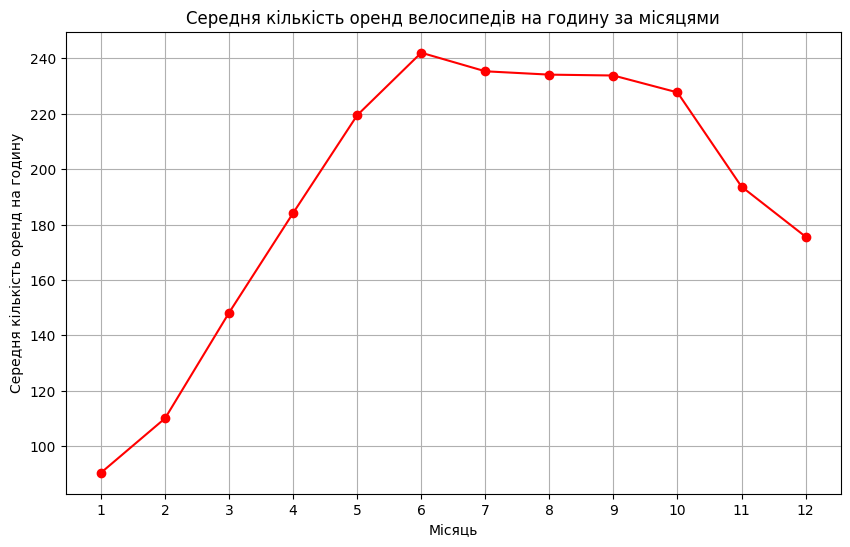

In [63]:
# Будуємо графік:

monthly_avg.plot(
    kind='line',
    figsize=(10, 6),
    color='red',                          # червона лінія
    marker='o',                           # маркери-кружечки
    grid=True,                            # сітка
    xticks=range(1, 13),                  # відповідає за створення рівно 12 поділок
    title='Середня кількість оренд велосипедів на годину за місяцями',
    xlabel='Місяць',
    ylabel='Середня кількість оренд на годину'
);

Питання для інтерпретації:

1. В які місяці спостерігається пік та спад оренди?

Найбільший пік оренди припадає на червень (242), далі стабільно висока кількість оренди у липня, серпня та вересні. І далі спостерігаємо спад. Найнижчі показники оренди становлять у січні (90).

2. Чи збігається ця закономірність з результатами з попереднього завдання?

Так, закономірність збішається із попередній завданням та графіком.

3. Як може вплинути клімат на оренду велосипедів протягом року?

Клімат прямопропорційно впливає на оренду велосипедів. Чим краща погода, тим більша оренда.

## Завдання 4: Розподіл погодних умов (Pie Chart)

**Завдання:**
1. Побудуйте кругову діаграму з часткою записів за погодними умовами
2. Додайте підписи з відсотками та легенду з описами погоди (1=ясно, 2=туман, 3=легкий дощ, 4=сильний дощ).
3. Визначте свої відмінні від стандартних кольори для відображення кожної категорії.
4. Дайте відповіді на питання нижче.

**Питання для інтерпретації:**
1. Яка погода переважає в датасеті?
2. Чи є дні із сильним дощем? Яка їх частка?
3. Як ви думаєте, як погодні умови впливають на попит на оренду велосипедів?

In [64]:
# Рахуємо кількість записів за погодними умовами:

weather_count = df['weather'].value_counts()

In [65]:
weather_count

,count
weather,
1,7192
2,2834
3,859
4,1


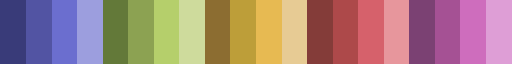

In [66]:
plt.cm.tab20b

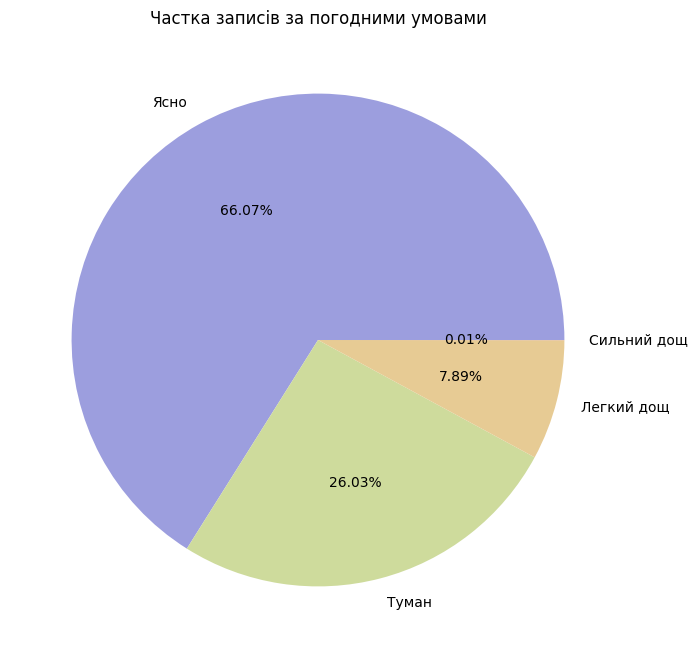

In [67]:
select_colors = [
    plt.cm.tab20b.colors[3],
    plt.cm.tab20b.colors[7],
    plt.cm.tab20b.colors[11],
    plt.cm.tab20b.colors[19]
]

weather_count.plot.pie(
    figsize=(8, 8),
    autopct='%1.2f%%',
    labels=['Ясно', 'Туман', 'Легкий дощ', 'Сильний дощ'],
    title='Частка записів за погодними умовами',
    ylabel='',
    colors=select_colors,     # у plot.pie() colors використовуєм у множині!!!
);

Очікуваний результат:

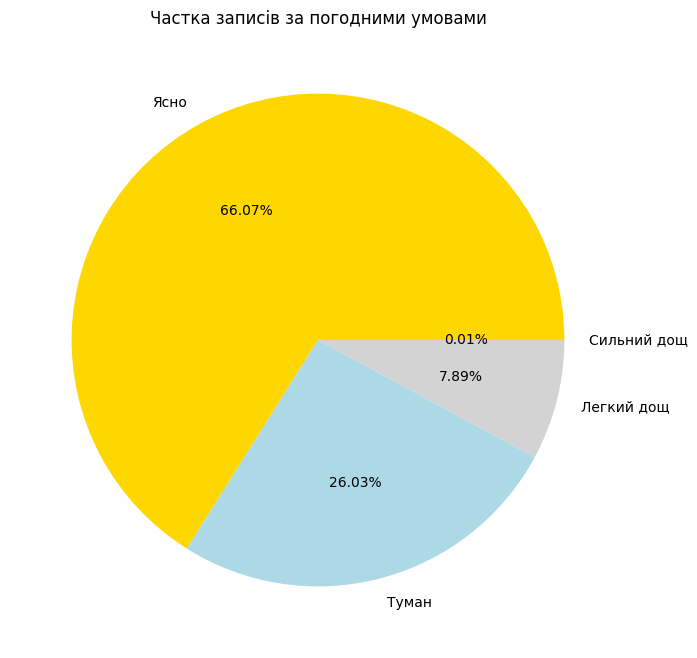

Питання для інтерпретації:

1. Яка погода переважає в датасеті?

В датасеті переважає сонячна погода (у 66,07% випадків).

2. Чи є дні із сильним дощем? Яка їх частка?

Дні із сильним дощем становлять 0,01% від загальної кількості.

3. Як ви думаєте, як погодні умови впливають на попит на оренду велосипедів?

В сонячні дні орендують велосипеди значно більше людей, ніж в дощові. Оскільки під дощем не сильно комфортно їздити на велосипеді.


## Завдання 5: Box Plot для аналізу викидів

**Завдання:**
Створіть коробковий графік (box plot) кількості орендованих велосипедів для кожного типу погоди.

Просунуте доповнення:
- Використайте горизонтальну орієнтацію.
- Позначте погодні умови не числом, а назвою на візуалізації.

Дайте відповіді на питання нижче.

**Питання для інтерпретації:**
1. При якій погоді найбільший розкид у кількості оренди?
2. Чи є викиди (outliers) в даних? При якій погоді?
3. При якій погоді медіанне значення оренди найвище?

In [68]:
# перезавантаження модуля plt, щоб прибрати помилки:

import importlib
import matplotlib.pyplot as plt

importlib.reload(plt)

<module 'matplotlib.pyplot' from '/usr/local/lib/python3.13/dist-packages/matplotlib/pyplot.py'>

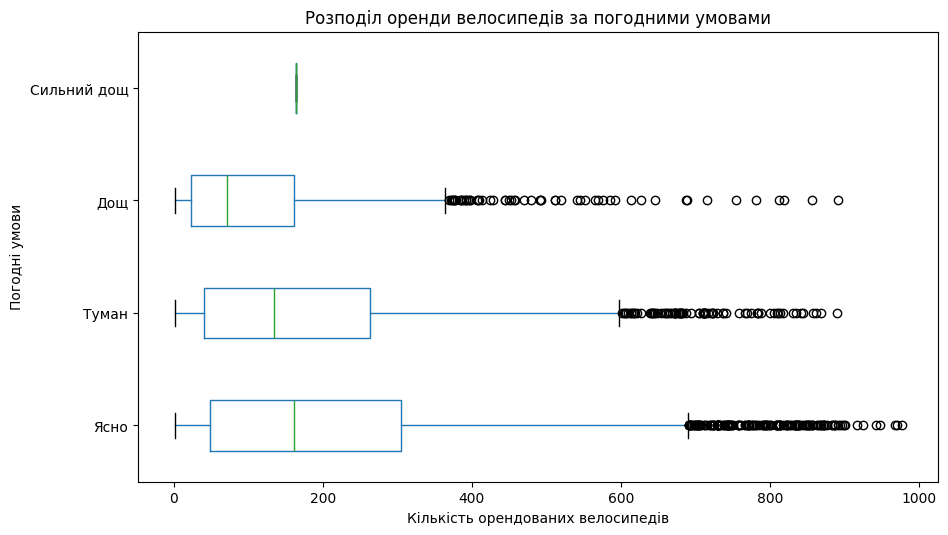

In [69]:
df.boxplot(                                 # будуємо на вихідному DataFrame df
    column='count',
    by='weather',
    figsize=(10, 6),
    grid = False,
    vert=False                                      # Горизонтальна орієнтація
)
                        # Замінюємо числа 1, 2, 3, 4 на текстові назви по осі Y
plt.yticks(
    ticks=[1, 2, 3, 4],
    labels=['Ясно', 'Туман', 'Дощ', 'Сильний дощ']
)

plt.title('Розподіл оренди велосипедів за погодними умовами')
plt.suptitle('')
plt.xlabel('Кількість орендованих велосипедів')
plt.ylabel('Погодні умови')
plt.show()


Питання для інтерпретації:

1. При якій погоді найбільший розкид у кількості оренди?

Найбільший загальний розкид при погоді Ясно (значення сягають майже 1000 оренд за годину).

2. Чи є викиди (outliers) в даних? При якій погоді?

Так, викиди є. Вони відображені у вигляді окремих кружечків праворуч від "вусів" графіка. Найбільша кількість викидів при погоді Ясно.

3. При якій погоді медіанне значення оренди найвище?

Найвище медіанне значення оренди при погоді Ясно, і трохи менше від нього - при погоді Туман.

## Завдання 6: Кореляція температури та оренди (Scatter Plot)

**Завдання:**
Побудуйте діаграму розсіювання залежності між температурою (`temp`) та загальною кількістю оренди (`count`). Розфарбуйте точки за сезонами, додайте напівпрозорість (alpha=0.6).

**Увага!** За замовченням буде колір

Дайте відповіді на питання нижче.

**Питання для інтерпретації:**
- Чи є зв'язок між температурою та кількістю оренди? Який?

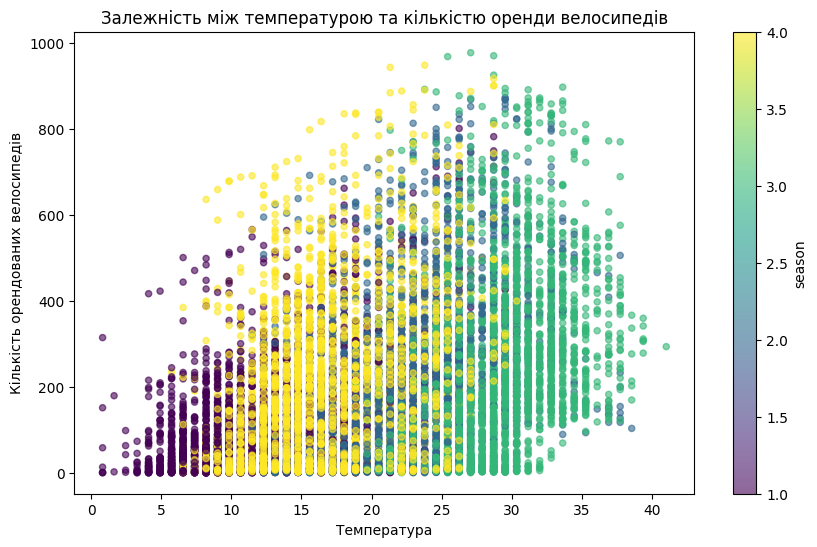

In [70]:
df.plot.scatter(
    x='temp',
    y='count',
    c='season',                                         # розфарбовуємо точки за стовпчиком season
    colormap='viridis',
    title='Залежність між температурою та кількістю оренди велосипедів',
    figsize=(10, 6),
    alpha=0.6
)
plt.xlabel('Температура')
plt.ylabel('Кількість орендованих велосипедів')
plt.show()

Питання для інтерпретації:

Чи є зв'язок між температурою та кількістю оренди? Який?

Так, зв'язок присутній. Зі збільшенням температури повітря кількість оренди помітно зростає. При температурі близько 25-30 градусів спостерігаються пікові значення оренди (800-1000).При перевищенні температури більше 30 градусів попит на оренду починає спадати, оскільки кататися на велосипеді в сильну спеку стає некомфортно.

## (Опціонально) Завдання 7: Порівняння користувачів (Stacked Bar Chart)

**Завдання:**
Ми хочемо дізнатись як по дням тижня беруть в середньому в оренду велосипеди випадкові і зареєстровані користувачі.

Створіть стовпчасту діаграму з накопиченням (bar з налаштуванням `stacked=True`), яка показує співвідношення випадкових (`casual`) та зареєстрованих (`registered`) користувачів по днях тижня за кількістю взятих ними велосипедів в оренду в середньому. Використайте різні кольори для типів користувачів.

Дайте відповіді на питання нижче.

**Питання для інтерпретації:**
1. В які дні тижня більше оренд від зареєстрованих користувачів?
2. Як ви можете пояснити таку різницю в поведінці користувачів протягом тижня?

In [71]:
# Агрегація: середнє значення casual та registered по днях тижня

rental_users = df.groupby('weekday')[['casual', 'registered']].mean()

In [72]:
rental_users

,casual,registered
weekday,,
Friday,31.001962,166.842381
Monday,29.843972,160.546744
Saturday,63.625000,133.040404
Sunday,57.051298,123.788474
Thursday,24.007083,173.289118
Tuesday,22.979207,166.744639
Wednesday,22.521599,165.889749


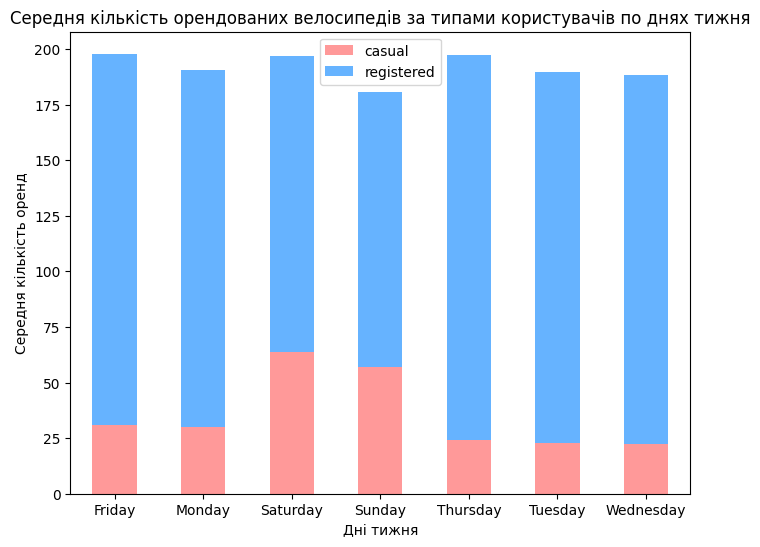

In [73]:
# Побудова стовпчастої діаграми з накопиченням (Stacked Bar Chart)

rental_users.plot.bar(
    stacked=True,
    figsize=(8, 6),
    color=['#ff9999', '#66b3ff'],      # різні кольори для casual та registered
    title='Середня кількість орендованих велосипедів за типами користувачів по днях тижня',
    xlabel='Дні тижня',
    ylabel='Середня кількість оренд',
    rot=0                               # робимо підписи днів тижня горизонтальними
);

Для послідовного відображення днів тижня потрібно їх корректно перевести в послідовний порядок.

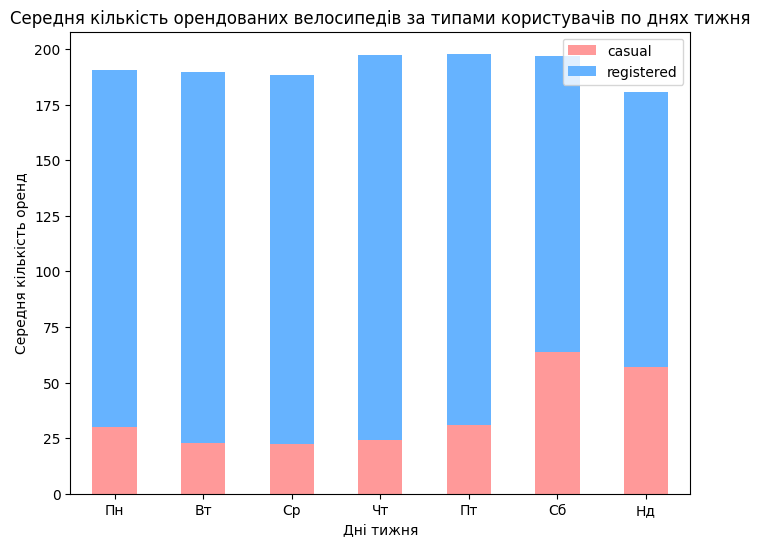

In [74]:
# Задаємо правильний календарний порядок англійською
days_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

# Словник для перекладу на українську
days_ua = {
     'Monday': 'Пн', 'Tuesday': 'Вт', 'Wednesday': 'Ср',
     'Thursday': 'Чт', 'Friday': 'Пт', 'Saturday': 'Сб', 'Sunday': 'Нд'
}

# Перевпорядковуємо за календарем та перейменовуємо
rental_users = rental_users.reindex(days_order).rename(index=days_ua)

# Побудова діаграми
rental_users.plot.bar(
    stacked=True,
    figsize=(8, 6),
    color=['#ff9999', '#66b3ff'],
    title='Середня кількість орендованих велосипедів за типами користувачів по днях тижня',
    xlabel='Дні тижня',
    ylabel='Середня кількість оренд',
    rot=0
);

Питання для інтерпретації:

1. В які дні тижня більше оренд від зареєстрованих користувачів?

Зареєстрованих користувачів більше в робочі дні тижня (з понеділка по п'ятницю).

2. Як ви можете пояснити таку різницю в поведінці користувачів протягом тижня?

Скоріш за все, зареєстровані користувачі беруть велосипеди в оренду для того, щоб доїхати на роботу. Тому вони зареєструвались і користуються постійно в робочі дні. А у вихідні з'являються звичайні користувачі, які беруть велосипеди в оренду для прогулянок або активного відпочинку.